# Mathematische OSS in der Praxis
## Logik, Optimierung, Graphentheorie und mehr mit SageMath

**Manfred Scheucher**  
Grazer Linuxtage 2026

<img src="figs/arrangement.png" width="30%">

---
## Was erwartet mich in diesem Vortrag?

* Slides in Jupyter Notebook — Markdown und Code gemischt
  * sonst LaTeX Beamer oder [IPE Drawing Editor](https://ipe.otfried.org/) (Vektorgrafiken oder ganze Slides)
* viele Beispiele
* schöne Bilder
* Code-Snippets in Python-Syntax
* Python-Kenntnisse hilfreich, aber nicht notwendig

---
## SageMath 

* Freie Software zur Lösung mathematischer Probleme
* vereint Stärken vieler Open-Source-Libraries
  * **PARI/GP, FLINT, NTL** — Zahlentheorie (elliptische Kurven, Polynome, Gitter)
  * **GAP, Singular** — Gruppen- und Ringtheorie, Gröbner-Basen
  * **Maxima, SymPy** — symbolische Algebra, Analysis
  * **GLPK** — lineare/ganzzahlige Optimierung (LP/IP/MILP)
  * **NumPy/SciPy** — numerisch
  * **NetworkX, Boost, Nauty** — Graphen, Automorphismen
  * **Matplotlib, Three.js, Jmol** — 2D/3D-Plots
  * ...
* einheitliches Python-Interface
  * große Teile in Cython (Performance, C/C++-Anbindung)
  * auch R, Octave, Mathematica, ... nutzbar
* 150+ Seiten Dokumentation mit Beispielen
    * [https://doc.sagemath.org/](https://doc.sagemath.org/)
* Installation: conda-forge, pip (Modularisierung in Arbeit)
    * [https://doc.sagemath.org/html/en/installation/](https://doc.sagemath.org/html/en/installation/)

---
## Warum nicht einfach C/C++ oder Python?

**C/C++ — Integer Overflow:**
```c
int x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 0  (Overflow!)
```

**C++ mit GMP** (GNU Multiple Precision Arithmetic Library) — beliebig große Ganzzahlen:
```c
#include <gmpxx.h>
mpz_class x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 1267650600228229401496703205376
```

**Python** — big integers out of the box:
```python
2**100  # → 1267650600228229401496703205376
```

**Aber — Gleitkomma:**
```c
#include <cmath>
float  x = sqrt(2.0f); printf("%.20f\n", x*x); // → 1.99999988079071044922
double x = sqrt(2.0);  printf("%.20f\n", x*x); // → 2.00000000000000044409
```

```python
import math
x = math.sqrt(2.0)
print(x*x)  # → 2.0000000000000004
```


Irrationale Zahlen sind zwar nicht in Floats darstellbar — aber hier fängts erst an!

## Irrationale Zahlen: Algebraisch vs. Transzendent

**Algebraische Zahlen** — Nullstellen von Polynomen mit ganzzahligen Koeffizienten:
- $\sqrt{2}$: Nullstelle von $x^2 - 2$
- $\sqrt[3]{5}$: Nullstelle von $x^3 - 5$

Durch Repräsentation als Polynom ist **exaktes Rechnen** möglich!

**Beispiel:**
```python
sqrt(6) / sqrt(2)   # → sqrt(3)
```

Intern: $z = x/y$ mit $x^2 = 6$, $y^2 = 2$ $\;\Rightarrow\;$ $z^2 = x^2/y^2 = 6/2 = 3$, also Minimalpolynom $z^2 - 3$.

**Transzendente Zahlen** — kein solches Polynom existiert für $\pi$, $e$, $\sin(1)$, ...

- aber: bekannte Identitäten sind in Sage symbolisch vorhanden:
```python
sin(pi)    # → 0
sin(pi/2)  # → 1
```
- Sage erkennt sogar Grenzwerte/Folgen/Reihen und formt um!
```python
n = var('n')
limit((1 + 1/n)^n, n=oo)  # → e
```

```python
n, x = var('n x')
sum(x^n / factorial(n), n, 0, oo)  # → e^x
```

*Anm: Kommerzielle Tools wie Wolfram Mathematica/Alpha können das natürlich auch — aber Sage ist OSS: wer will, kann bis ganz unten lesen und verstehen.*

---
## Basics

Wie Verwenden?
* Jupyter Notebook `sage --notebook`
* CommandLineInterface `sage`
* Script mit Parameter `sage script.sage`

In [17]:
print("Hallo Welt!") # Python Input/Output
print("Hallo Graz!")

Hallo Welt!
Hallo Graz!


In [19]:
"Hallo Welt!" 
"Hallo Graz!" # Jupyter Notebook zeigt letztes an

'Hallo Graz!'

In [72]:
def f(x): return x*x
print([f(x) for x in range(10)]) # Funktionen, List Comprehension, etc.

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [80]:
def my_generator():
    s = 'hallo'
    while True:
        yield s
        s += 'X'

g = my_generator()
for i in range(10): print(i,next(g)) # Generatoren

0 hallo
1 halloX
2 halloXX
3 halloXXX
4 halloXXXX
5 halloXXXXX
6 halloXXXXXX
7 halloXXXXXXX
8 halloXXXXXXXX
9 halloXXXXXXXXX


**Übersicht über Objekte und Methoden**

In [109]:
G=Graph()
G?

Type:        Graph
String form: Graph on 0 vertices
Length:      0
File:        /var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/sage/graphs/graph.py
Docstring:  
Undirected graph.

A graph is a set of vertices connected by edges. See the
https://en.wikipedia.org/wiki/Graph_(mathematics) for more
information. For a collection of pre-defined graphs, see the
"graph_generators" module.

A "Graph" object has many methods whose list can be obtained by typing
"g.<tab>" (i.e. hit the "Tab" key) or by reading the documentation of
"graph", "generic_graph", and "digraph".

INPUT:

By default, a "Graph" object is simple (i.e. no *loops* nor *multiple
edges*) and unweighted. This can be easily tuned with the appropriate
flags (see below).

* "data" -- can be any of the following (see the "format" argument):

  1. "Graph()" -- build a graph on 0 vertices.

  2. "Graph(5)" -- return an edgeless graph on the 5 vertices 0,...,4.

  3. "Graph([list_of_vertices, list_of_edges])" -- returns 

In [112]:
#G.<tabulator>     ->  Liste von Attributen und Methoden
G.is_connected?

Signature:      G.is_connected(G, forbidden_vertices=None)
Docstring:     
Check whether the (di)graph is connected.

Note that in a graph, path connected is equivalent to connected.

INPUT:

* "G" -- the input graph

* "forbidden_vertices" -- list (default: "None"); set of vertices to
  avoid during the search

See also:

  * "is_biconnected()"

EXAMPLES:

   sage: from sage.graphs.connectivity import is_connected
   sage: G = Graph({0: [1, 2], 1: [2], 3: [4, 5], 4: [5]})
   sage: is_connected(G)
   False
   sage: G.is_connected()
   False
   sage: G.add_edge(0,3)
   sage: is_connected(G)
   True
   sage: is_connected(G, forbidden_vertices=[3])
   False
   sage: is_connected(G, forbidden_vertices=[1])
   True
   sage: D = DiGraph({0: [1, 2], 1: [2], 3: [4, 5], 4: [5]})
   sage: is_connected(D)
   False
   sage: D.add_edge(0, 3)
   sage: is_connected(D)
   True
   sage: D = DiGraph({1: [0], 2: [0]})
   sage: is_connected(D)
   True
Init docstring: Initialize self.  See help(type(self))

**Zeit messen in Jupyter**

In [86]:
%%time 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) 

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 2.01 s, sys: 20.6 ms, total: 2.03 s
Wall time: 2.03 s


In [87]:
%%time
@cached_function 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) # Dynamische Programmierung: Zwischenergebnisse speichern

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 213 μs, sys: 57 μs, total: 270 μs
Wall time: 225 μs


**Command-Line Parameter**
* Ausführung auch via commandline: `sage script.sage` bzw `time sage script.sage`
* Parameter `argv` bzw `argparse`

```python
# https://docs.python.org/3/library/argparse.html
parser.add_argument('filename') # mandatory filename
parser.add_argument('-c', '--count', type=int) # optional integer
parser.add_argument('-v', '--verbose', action='store_true') # optional flag
```

**Multithreading**

In [25]:
%%time 
import time
def f(i): 
    time.sleep(float(0.1)) 
    return i
print([f(i) for i in range(50)]) # 5 Sekunden auf 1 CPU (single-threaded)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 8.15 ms, sys: 2.15 ms, total: 10.3 ms
Wall time: 5.19 s


In [88]:
%%time 
@parallel
def f(i): 
    time.sleep(float(0.1)) 
    return i
print(list(f(range(50)))) # 0.1 Sekunden (parallelisiert in Jupyter)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 1.47 ms, sys: 2.28 ms, total: 3.75 ms
Wall time: 105 ms


Sideremarks: 
* in diesem Beispiel braucht selbst `print(list(f(range(1000))))` nur 0.1 sec da kein busy wait!
* für Sage-Script `multiprocessing.Pool.map` verwenden, siehe [pool_example.sage](pool_example.sage)

In [93]:
# Zeitmessen und Parallelisierung in CL
!sage pool_example.sage 

11:20:26.404 single-thread start
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
11:20:31.586 single-thread stop
11:20:31.657 parallel start
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
11:20:33.568 parallel stop


---
## Zahlentheorie & Kryptographie

In [119]:
x = 1337
print(x.is_prime())
print(x.factor())
print(next_prime(x))
# Liste von Methoden durch Eingabe von: x.<tabulator>

False
7 * 191
1361


**Modulare Arithmetik** (RSA u.a. Cryptosysteme):

$$2^{12} \mod 17 = \;?$$


In [116]:
power_mod(2, 12, 17)
# 2^12 = 2^(4*3) = (2^4)^3 = 16^3 = (-1)^3 = -1 = 16 mod 17

16

Funktionen und Doku zu **ECC** (Elliptic Curve Cryptography):
<a href="https://doc.sagemath.org/html/en/reference/arithmetic_curves/index.html">https://doc.sagemath.org/html/en/reference/arithmetic_curves/index.html</a>

---
## Kurvendiskussion


Klassische Matura-Aufgaben

In [121]:
# Beispiel 1
x = var('x')
f = 1-x^2
print(f) # Textuelle Ausgabe
f.show() # Formatierte Ausgabe

-x^2 + 1


-x^2 + 1

In [122]:
print("f'(x) =", f.diff()) # Symbolische Ableitung
print("F(x)  =", f.integrate(x)) # Stammfunktion

f'(x) = -2*x
F(x)  = -1/3*x^3 + x


In [123]:
f.roots() # nullstellen mit multiplizitäten

[(-1, 1), (1, 1)]

In [124]:
f.find_local_maximum(-1,1) # numerische suche nach lokalem maximum (y,x)

(1.0, 4.933333305577758e-09)

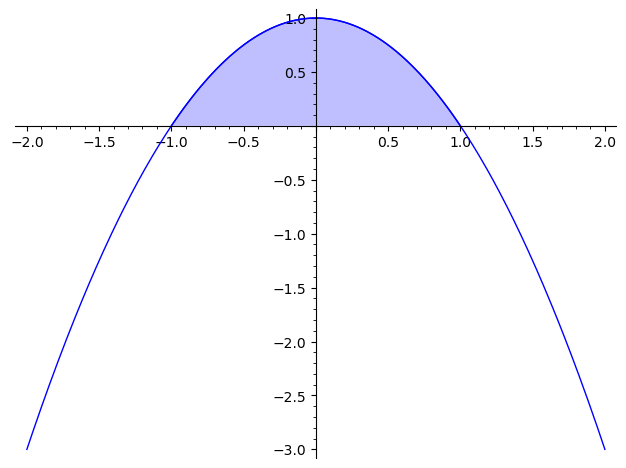

In [125]:
# Plot: Fläche unter Kurve
p  = plot(f, (x, -2, 2))
p += plot(f, (x, -1, 1), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [161]:
# Flächenbestimmung
I = integrate(f, x, -1, 1)
print(f"Fläche: {I} ≈ {float(I)}") # Rechnung symbolisch, Ergebnis numerisch umwandeln

Fläche: 4/3 ≈ 1.3333333333333333


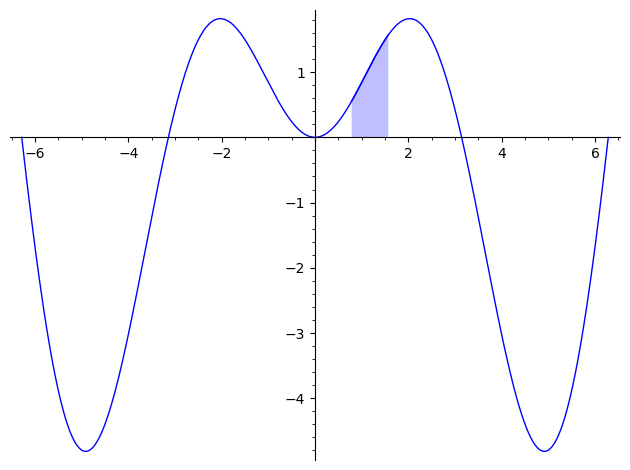

In [150]:
# Beispiel 2: Elementare Funktionen (Sinus, Kosinus,...)
f = x*sin(x)

p  = plot(f, (x, -2*pi, 2*pi))
p += plot(f, (x, pi/4, pi/2), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [33]:
f.find_local_maximum(0,pi) # zuerst y wert, dann x wert

(0.9999999999999999, 8.795835831831328e-09)

In [141]:
# Flächenbestimmung
I = integrate(f, x, pi/4, pi/2)
print(f"Fläche: {I} ≈ {float(I)}") # Rechnung symbolisch, Ergebnis numerisch umwandeln

Fläche: 1/8*sqrt(2)*pi - 1/2*sqrt(2) + 1 ≈ 0.8482535860832482


In [142]:
# beliebige Präzision (Anzahl Bits)
for prec in [30,100,300,1000]:
    R = RealField(prec)
    print(f"{prec} \t-> {R(I)}")

30 	-> 0.84825359
100 	-> 0.84825358608324825647614076165
300 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722100
1000 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722099681774868302919353470197450408082531786867834830224857546409333962203298519505731895261281732387086924235670892379900332787149289022340125581320941646902546785000861569051624975354245554175904560251983112700234


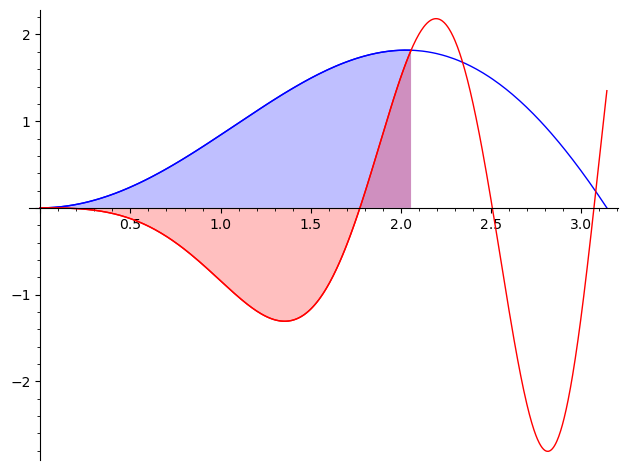

In [132]:
# Plot: Fläche zwischen Kurven 
f = x*sin(x)
g = -x*sin(x*x)

x1 = (f-g).find_root(2,2.3)
p  = plot(f, (x, 0, pi), color='blue')
p += plot(f, (x, 0, x1), color='blue', fill=True, fillcolor='blue', fillalpha=0.25)

p += plot(g, (x, 0, pi), color='red')
p += plot(g, (x, 0, x1), color='red', fill=True, fillcolor='red', fillalpha=0.25)
p.show()

In [128]:
print((f-g).find_root(2,2.3)) # Numerische Suche nach Schnittstellen von f und g, bei Elementaren funktionen nicht symbolisch möglich
print((f-g).find_root(2.3,3))
print((f-g).find_root(3,3.5))

2.0560096453612196
2.3416277185114787
3.0799958958578673


In [ ]:
# Symbolische Flächenbestimmung
I = integrate(f-g, x, pi/4, pi/2)
print(f"Fläche: {I} ≈ {float(I)}")

---
## Gleichungssysteme

**Schnitt von zwei Geraden:** $2x+y=4$, $x+2y=4$:

In [135]:
x, y = var('x y')
solve([2*x+y==4,x+2*y==4],x,y) # (4/3, 4/3)

[[x == (4/3), y == (4/3)]]

Oder etwas umständlicher:
$$A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}, \quad b = \begin{pmatrix} 4 \\ 4 \end{pmatrix}, \quad Ax = b \;\Rightarrow\; x = A^{-1} b$$

sol: (4/3, 4/3)


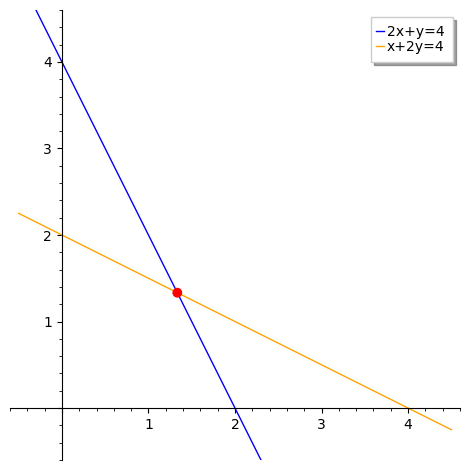

In [136]:
A = matrix([[2,1],[1,2]])
b = vector([4,4])
sol = A.inverse() * b # (4/3, 4/3)
print(f"sol: {sol}")

x = var('x')
p  = plot(4 - 2*x, (x, -0.5, 3), color='blue',   legend_label='2x+y=4')
p += plot(2 - x/2, (x, -0.5, 4.5), color='orange', legend_label='x+2y=4')
p += point(sol, size=50, color='red', zorder=5)
p.show(aspect_ratio=1, xmin=-0.5, xmax=4.5, ymin=-0.5, ymax=4.5)

**Schnitt von zwei Kreisen:**

$$C_1: (x-1)^2 + y^2 = 4 \qquad C_2: (x+1)^2 + y^2 = 4$$

In [153]:
x, y = var('x y')
C1 = (x-1)^2 + y^2 == 4
C2 = (x+1)^2 + y^2 == 4

In [154]:
solutions = solve([C1, C2], x, y) # Symbolische Schnittpunkte
for s in solutions:
    sx = s[0].rhs()
    sy = s[1].rhs()
    print(f"{s} -> ({sx},{sy}) ≈ ({RR(sx)},{RR(sy)})")

[x == 0, y == -sqrt(3)] -> (0,-sqrt(3)) ≈ (0.000000000000000,-1.73205080756888)
[x == 0, y == sqrt(3)] -> (0,sqrt(3)) ≈ (0.000000000000000,1.73205080756888)


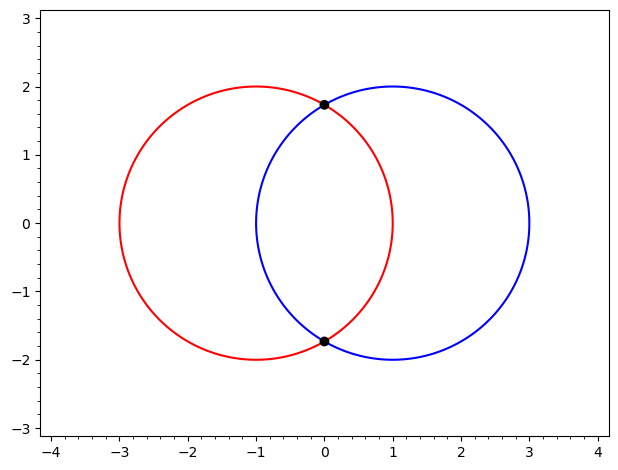

In [155]:
p  = implicit_plot(C1.lhs() - C1.rhs(), (x, -4, 4), (y, -3, 3), color='blue')
p += implicit_plot(C2.lhs() - C2.rhs(), (x, -4, 4), (y, -3, 3), color='red')
for s in solutions:
    sx = s[0].rhs()
    sy = s[1].rhs()
    p += point((RR(sx), RR(sy)), size=50, color='black', zorder=2)
p.show(aspect_ratio=1)

**Idee hinter symbolischen Lösung:**

In [41]:
# jeder Schnittpunkt (x,y) ist Nullstelle beider Gleichungen 
f1 = (x-1)^2 + y^2 - 4 
f2 = (x+1)^2 + y^2 - 4 

In [42]:
# ... und Nullestelle von f3 = f1-f2
f3 = (f1-f2)
print(f3) 
print(f3.simplify_full()) # 4x ist nur Null wenn x=0 

-(x + 1)^2 + (x - 1)^2
-4*x


In [43]:
# ... und Nullstelle von f4 = f1+f2, insbesondere wenn x=0 gesetzt
f4 = (f1+f2)
print(f4)
print(f4(x=0))
print(f4(x=0).roots())

(x + 1)^2 + (x - 1)^2 + 2*y^2 - 8
2*y^2 - 6
[(-sqrt(3), 1), (sqrt(3), 1)]


Anm: Lösungen zu finden ist im Allgemeinen schwer, doubly exponential

## 

---
## Geometrie

2D und 3D Strukturen mit wenig Code visualisieren

**Beispiel:** 

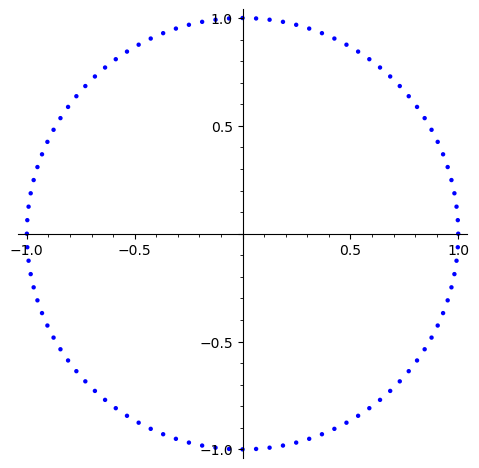

In [50]:
n = 100
point2d([(cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)]).show(aspect_ratio=1)

In [51]:
p = point3d([(cos(x*2*pi/n),sin(x*2*pi/n),0) for x in range(n)],color='blue')
p += point3d([(cos(x*2*pi/n),0,sin(x*2*pi/n)) for x in range(n)],color='red')
p += point3d([(0,cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)],color='green')
p.show(aspect_ratio=1)

Graphics3d Object

In [160]:
import random
from scipy.spatial import Voronoi, ConvexHull

def new_points():
    return [(random.uniform(0,1), random.uniform(0,1)) for _ in range(20)]

pts = new_points()
hull2d = ConvexHull(pts)
hull_indices = set(hull2d.vertices)

@interact
def geo_demo(mode=selector(['Nearest Neighbor', 'Voronoi', 'Convex Hull'], label='Modus')):
    global pts, hull2d, hull_indices
    hull2d = ConvexHull(pts)
    hull_indices = set(hull2d.vertices)

    inner = [pts[i] for i in range(len(pts)) if i not in hull_indices]
    outer = [pts[i] for i in hull_indices]

    p = points(inner, size=30, color='black', zorder=5)
    p += points(outer, size=30, color='blue', zorder=5)

    if mode == 'Nearest Neighbor':
        for i, (ax, ay) in enumerate(pts):
            best = min((j for j in range(len(pts)) if j != i),
                       key=lambda j: (pts[j][0]-ax)**2 + (pts[j][1]-ay)**2)
            bx, by = pts[best]
            p += arrow((ax, ay), (bx, by), color='blue', width=1, arrowsize=2)

    elif mode == 'Voronoi':
        vor = Voronoi(pts)
        for simplex in vor.ridge_vertices:
            if -1 not in simplex:
                x0, y0 = vor.vertices[simplex[0]]
                x1, y1 = vor.vertices[simplex[1]]
                p += line([(x0,y0),(x1,y1)], color='red')

    elif mode == 'Convex Hull':
        hull_pts = [pts[i] for i in hull2d.vertices]
        p += polygon(hull_pts, color='lightblue', alpha=0.5)
        p += line(hull_pts+[hull_pts[0]], color='blue', thickness=2)

    p.show(axes=False, frame=True, xmin=-0.05, xmax=1.05, ymin=-0.05, ymax=1.05)

Interactive function <function geo_demo at 0x34c280e00> with 1 widget
  mode: Dropdown(description='Modus', options=('Nearest Neighbor', 'Voronoi', 'Convex Hull'), value='Nearest Neighbor')

In [161]:
# viele geometrische Formen wie Ikosaeder verfügbar
I = polytopes.icosahedron()
print("Ecken:", len(I.vertices()))
print("Flächen:", len(I.faces(2)))
I.plot()

Ecken: 12
Flächen: 20


Graphics3d Object

In [147]:
import random
from scipy.spatial import ConvexHull
import numpy as np

random.seed()  # system time
pts3 = [(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1)) for _ in range(30)]
arr3 = np.array(pts3)

hull3 = ConvexHull(arr3)
hull_idx3 = set(hull3.vertices)

p3 = point3d([pts3[i] for i in hull_idx3], size=10, color='blue')
p3 += point3d([pts3[i] for i in range(len(pts3)) if i not in hull_idx3], size=10, color='black')

for simplex in hull3.simplices:
    tri = [pts3[i] for i in simplex]
    p3 += polygon3d(tri, color='lightblue', alpha=0.3)

p3.show()

Graphics3d Object

**3D Pseudohyperebenen-Arrangement:**

[https://helenabergold.github.io/supp/3d_signotopes/nonextendable_sign48_pshyperplane.html](https://helenabergold.github.io/supp/3d_signotopes/nonextendable_sign48_pshyperplane.html)

[lasagne3d/example_pshyperplanes.html](lasagne3d/example_pshyperplanes.html)

### Arrangements auf Kugel und Ebene in Relation

<img src="figs/apc_2019_p11.png" width="80%">


<img src="figs/apc_2019_p10.png" width="80%">

* Geometrische Objekte durch Graphen repräsentieren
* Koordinaten irrelevant, nur Kombinatorik/Topologie erfasst
* "Gleichheitstest" via Graphenisomorphie

**Primal-Graph:** Schnittpunkte → Knoten, Bögen → Kanten

**Dual-Graph:** Zellen → Knoten, gemeinsame Kante → Kante

**Primal-Dual:** Kombination beider Sichten

<img src=figs/arrangement_graphs.png width=80%>

Berechnungen mit Sage, alle Objekte als planare Graphen kodiert.
Visualisierung ins IPE-Format exportiert — erlaubt manuelles Überarbeiten und Export als PDF.
(Direkter SVG/PDF-Export aus Sage möglich, aber Nachbearbeitung aufwändiger.)

[IPE Drawing Editor](https://ipe.otfried.org/) ([im Browser ausprobieren](https://ipe-web.otfried.org/index.html))



Gegenbeispiel zu Vermutung aus 1970ern:

<img src=figs/arrangement.png width=50%>


[(0, 29), (0, 30), (0, 31), (1, 11), (1, 12), (1, 13), (2, 19), (2, 22), (2, 10), (3, 17), (3, 20), (3, 8), (4, 18), (4, 21), (4, 9), (5, 24), (5, 26), (5, 14), (6, 25), (6, 27), (6, 15), (7, 16), (7, 23), (7, 28), (8, 11), (8, 12), (8, 14), (9, 11), (9, 13), (9, 15), (10, 16), (10, 12), (10, 13), (11, 18), (12, 17), (13, 19), (14, 18), (14, 20), (15, 19), (15, 21), (16, 17), (16, 22), (17, 23), (18, 24), (19, 25), (20, 23), (20, 26), (21, 24), (21, 27), (22, 25), (22, 28), (23, 30), (24, 29), (25, 31), (26, 29), (26, 30), (27, 29), (27, 31), (28, 30), (28, 31)]


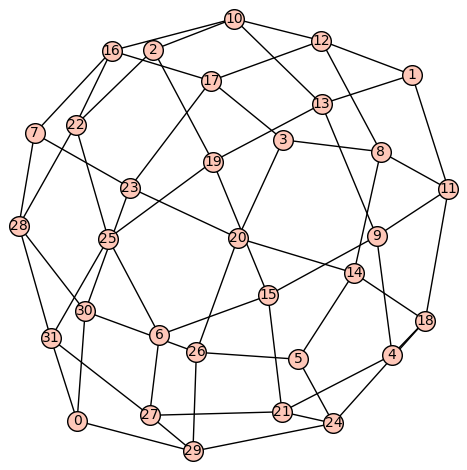

In [142]:
# Dual-Graph des Arrangements als sparse6-String
s = ":_gBca`GH`GI`HIdGeHfIbKOcJMaLNbMcNaOfPSdQTeRUdSeTfU_WYZ_VY[_XZ["
g = Graph(s)
print(g.edges(labels=False))
g.plot()

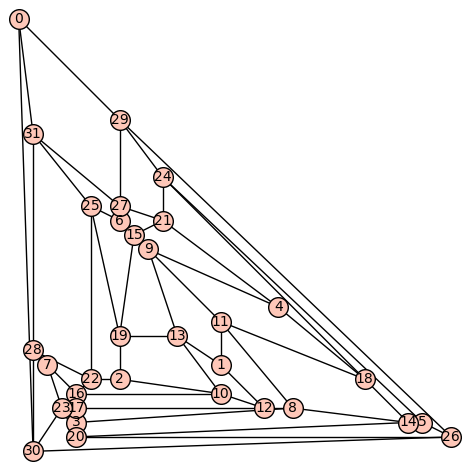

In [143]:
# planare darstellung
g.is_planar(set_pos=1)
g.plot()

---
## Graphen

* eigene native Graphbibliothek (Cython/C-Backend)  
* Schnittstellen zu **Boost Graph Library** (C++) und **NetworkX** (Python).

Knoten: ['A', 'B', 'C', 'D', 'E', 'F']
Kanten: [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F')]
planar: True


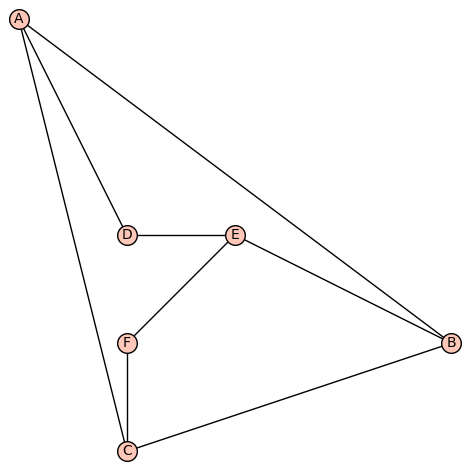

In [165]:
# Graph definieren und plotten
G = Graph({'A': ['B','C','D'], 'B': ['C','E'], 'C': ['F'], 'D': ['E'], 'E': ['F'], 'F': []})
print("Knoten:", G.vertices())
print("Kanten:", G.edges(labels=False))
print("planar:", G.is_planar(set_pos=True)) # planare Zeichnung falls vorhanden, optional
G.plot()

Chromatische Zahl: 3
Färbung: [['A', 'E'], ['B', 'D', 'F'], ['C']]


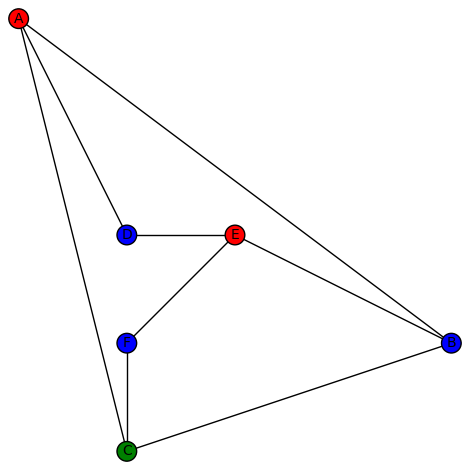

In [164]:
# Graphfärbung
chi = G.chromatic_number()
print("Chromatische Zahl:", chi)

coloring = G.coloring()
print("Färbung:", coloring)

G.plot(vertex_colors={
    'red':   coloring[0],
    'blue':  coloring[1],
    'green': coloring[2] if len(coloring) > 2 else []
})

In [204]:
# paarweise Kürzeste Wege
algo = choice(["BFS","Floyd-Warshall-Cython","Floyd-Warshall-Python","Dijkstra_NetworkX","Dijkstra_Boost","Johnson_Boost"])
# Liste via "G.distance_all_pairs?"
print("Algorithmus:",algo)
D = G.distance_all_pairs(algorithm=algo)
vertices = sorted(G.vertices())

print("Distanzmatrix:")
header = "    " + "  ".join(f"{v:>3}" for v in vertices)
print(header)
for u in vertices:
    row = f"{u:>3} " + "  ".join(f"{D[u][v]:>3}" for v in vertices)
    print(row)

Algorithmus: Johnson_Boost
Distanzmatrix:
      A    B    C    D    E    F
  A   0    1    1    1    2    2
  B   1    0    1    2    1    2
  C   1    1    0    2    2    1
  D   1    2    2    0    1    2
  E   2    1    2    1    0    1
  F   2    2    1    2    1    0


---
## Lineare Programmierung (LP)

mathematisches Verfahren zur Optimierung (Maximierung/Minimierung) einer linearen Zielfunktion unter Einhaltung linearer Nebenbedingungen

**Beispiel**
$$\max\; x + y$$

$$\begin{align}
\text{s.t.} \quad 2x + y &\leq 4 \quad (1)\\
x + 2y &\leq 4 \quad (2)\\
x, y &\geq 0
\end{align}$$

**Simplex:** wandert entlang Ecken des zulässigen Bereichs:
$(0,0) \;\to\; (2,0) \;\to\; z^* = (4/3,\, 4/3)$

Rote Linie: Zielfunktion $z = x+y = 8/3$ durch Optimum.

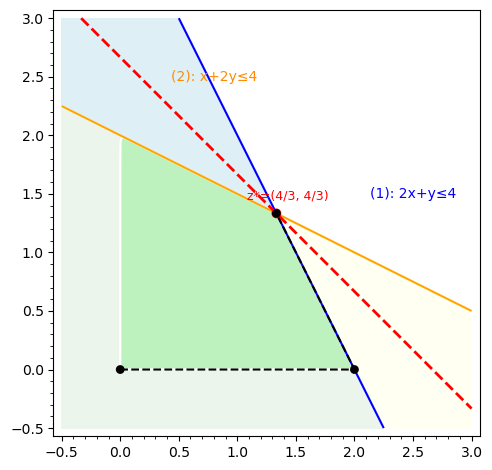

In [209]:
x, y = var('x y')

r1 = region_plot(2*x + y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightblue', alpha=0.4)
r2 = region_plot(x + 2*y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightyellow', alpha=0.4)
r3 = region_plot([x >= 0, y >= 0, 2*x + y <= 4, x + 2*y <= 4], (x,-0.5,3), (y,-0.5,3), incol='lightgreen', alpha=0.5)

l1 = implicit_plot(2*x + y - 4, (x, -0.5, 3), (y, -0.5, 3), color='blue')
l2 = implicit_plot(x + 2*y - 4, (x, -0.5, 3), (y, -0.5, 3), color='orange')

zline   = implicit_plot(x + y - 8/3, (x, -0.5, 3), (y, -0.5, 3), color='red', linestyle='--', linewidth=2)
opt     = point((4/3, 4/3), size=50, color='red', zorder=5)
corners = points([(0,0),(2,0),(4/3,4/3)], size=40, color='black', zorder=5)
path    = line([(0,0),(2,0),(4/3,4/3)], color='black', linestyle='--', thickness=1.5)

p = r1+r2+r3+l1+l2+zline+opt+corners+path
p += text("(1): 2x+y≤4",    (2.5, 1.5),          color='blue',       fontsize=10)
p += text("(2): x+2y≤4",    (0.8, 2.5),          color='darkorange', fontsize=10)
p += text("z*=(4/3, 4/3)",  (4/3+0.1, 4/3+0.15), color='red',        fontsize=9)
p.show(aspect_ratio=1)

---
## Mixed Integer Linear Programming (MILP)

**Gewinnmaximierung im Stall**

Variablen: $x_1$ = Schweine, $x_2$ = Hühner, $x_3$ = Kühe — jeweils **ganzzahlig, nicht-negativ**.

$$\max \; 30 x_1 + 5 x_2 + 50 x_3$$

$$\text{s.t.} \quad
\underbrace{50 x_1 + 10 x_2 + 200 x_3}_{\text{Wasser (L/Tag)}} \leq 400$$

$$\underbrace{3 x_1 + 0.5 x_2 + 8 x_3}_{\text{Futter (kg/Tag)}} \leq 40$$

$$\underbrace{x_1 + 0.1 x_2 + x_3}_{\text{Stallplätze}} \leq 7$$

$$x_1, x_2, x_3 \in \mathbb{Z}_{\geq 0}$$

In [205]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(integer=True, nonnegative=True)

p.set_objective(30*x[1] + 5*x[2] + 50*x[3])          # max Profit (€)

p.add_constraint(50*x[1] + 10*x[2] + 200*x[3] <= 400)  # Wasser (L/Tag)
p.add_constraint( 3*x[1] +  0.5*x[2] +  8*x[3] <= 40)   # Futter (kg/Tag)
p.add_constraint( 1*x[1] +  0.1*x[2] +    1*x[3] <= 7)      # Stallplätze

p.solve()

print(f"Schweine: {float(p.get_values(x[1]))}")
print(f"Hühner:   {float(p.get_values(x[2]))}")
print(f"Kühe:     {float(p.get_values(x[3]))}")
print(f"Profit:   € {float(p.get_objective_value())}")

Schweine: 6.0
Hühner:   10.0
Kühe:     0.0
Profit:   € 229.99999999999997


### Encoding & Solver-Effizienz

- Modellierung oft **straight-forward** — aber Encoding-Entscheidungen können Laufzeit **drastisch** beeinflussen
- Wenige Variablen & Constraints gute Heuristik,
- Hilfsvariablen 
- **Symmetrien** im Suchraum werden von Solvern meist *nicht* erkannt → manuell brechen
- **Dualität**: Maximierungsproblem ↔ äquivalentes Minimierungsproblem
- SAT ist Spezialfall von MILP (nur 0/1-Variablen, Constraints als Summe ≥ 1)

**Anmerkungen:**
- Hochdimensional: Dimension = Anzahl Variablen, exponentiell viele Ecken möglich
- Simplex: im worst case exponentiell — in der Praxis aber sehr schnell
- **Innere-Punkte-Methode**: (schwach) polynomiell
- In der Praxis: Millionen von Constraints möglich (GLPK, Gurobi, ...)

---
## Anwendung: Graphen auf Punktmengen

Nicht jeder Graph lässt sich auf jeder Punktmenge (ohne Kantenkreuzungen) einbetten:

<img src="figs/lshape.png" width="60%">

**Idee:** Tabelle vorberechnen: {g,p} = 1$ falls Graph $ auf Punktmenge $ einbettbar, sonst /bin/zsh$.

**Frage:** Wie viele Punktmengen reichen aus, um alle Graphen abzudecken?

12182\min \sum_p x_p12182

12182	ext{s.t.} \quad \sum_p a_{g,p} \cdot x_p \geq 1 \quad orall g \qquad (	ext{jeder Graph wird abgedeckt})12182

12182x_p \in \{0,1\} \quad (	ext{Punktmenge } p 	ext{ ausgewählt?})12182

Set-Covering-Instanz — direkt als IP formulierbar, Tabelle {g,p}$ vorberechnet mit Sage.

---
## Integer Programming (IP / MILP)

Integer-Constraints → **NP-schwer**

**Spezialfall:** Variablen $\in \{0,1\}$ → direkt SAT-Instanz

Constraints als Summen umschreiben:
$$x_1 \lor x_2 \lor x_3 \quad\Leftrightarrow\quad x_1 + x_2 + x_3 \geq 1$$
$$\lnot x_1 \lor \lnot x_2 \quad\Leftrightarrow\quad x_1 + x_2 \leq 1$$

**Umgekehrt:** Teilsummen durch Indikatorvariablen linearisieren:

$$x_1+x_2+x_3+x_4 = 4 \quad\text{(alle müssen 1 sein)}$$

$$u := x_1+x_2 \quad (3 \text{ Werte}), \quad
  v := u+x_3  \quad (4 \text{ Werte}), \quad
  w := v+x_4  \quad (5 \text{ Werte})$$

$3+4+5$ Indikatorvariablen statt $2^4$ — auch für bounded integer Variables.

**OSS:** GLPK, CBC — kommerziell: Gurobi (Stand der Technik)

Viel Theorie: Dualität, Branch-and-Cut, Schnittebenenverfahren.

---
## SAT

Bereits gezeigt — kurze Wiederholung:

- Variablen $\in \{0,1\}$, Formel in CNF: Konjunktion von Klauseln
- NP-vollständig (Cook 1971)
- Moderne Solver: CaDiCaL, Kissat, Glucose — extrem schnell in der Praxis
- Encoding-Qualität entscheidend für Laufzeit

**OSS:** CaDiCaL, Kissat, pysat (Python-Wrapper)

---
## SMT — Satisfiability Modulo Theories

SAT + Theorien: Arithmetik, Arrays, Bitvektoren, ...

Beispiel: Ist $x^2 + y^2 = 1 \land x = y \land x > 0$ erfüllbar?

```python
from z3 import *
x, y = Reals('x y')
s = Solver()
s.add(x**2 + y**2 == 1, x == y, x > 0)
print(s.check())   # sat
print(s.model())   # [x = ..., y = ...]
```

**Anwendung:** Formale Verifikation von Algorithmen (z.B. Bubblesort korrekt?)

**OSS:** Microsoft Z3 (auch Python-API), CVC5

---
## SAT Solver

**Hinweis:** Die SAT-Solver-Implementierungen in Sage sind veraltet (PicoSAT etc.) und nicht mehr zeitgemäß — aktuelle Solver sind CaDiCaL, Kissat, Glucose.

Wir verwenden stattdessen **pysat** — einfach installierbar, gleiche Syntax, aktuelle Solver:

```
pip install python-sat
```

In [ ]:
# pip install python-sat
from pysat.solvers import Cadical195

# Formel: (x1 ∨ x2) ∧ (¬x1 ∨ x3) ∧ (¬x2 ∨ ¬x3)
cnf = [
    [1, 2],    # x1 oder x2
    [-1, 3],   # nicht x1 oder x3
    [-2, -3],  # nicht x2 oder nicht x3
]

solver = Cadical195(bootstrap_with=cnf)
for model in solver.enum_models():
    print(model)

---
## Komplexität & NP

**Häufiges Missverständnis:** NP ≠ "nicht-polynomiell"

NP = **N**ichtdeterministisch **P**olynomiell  
→ bisher kein deterministischer Poly-Algorithmus gefunden, aber P=NP nicht ausgeschlossen!

### Überraschungen der letzten Jahrzehnte

- **Primfaktorisierung**: lange als "quadrathart" eingeschätzt → General Number Field Sieve (GNFS): subexponentiell
- **Graphisomorphie**: lange offen → Babai 2015: quasipolynomiell
- **3SUM**: jahrzehntelang als $\Theta(n^2)$-hart bezeichnet → 2014: $O(n^2 \log\log n / \log n)$

---

Falls die besten Tools nicht durchkommen: manchmal hilft es zu wissen, dass ein Problem **NP-schwer** ist —  
dann MILP/SAT einsetzen statt selbst "Zähne ausbeißen".

### Approximation

Wenn exakt zu teuer: **Approximationsalgorithmen** — für reale Anwendungen oft gut genug.

- **Traveling Salesman (TSP)**: NP-schwer, auch euklidisch — aber $(1+\varepsilon)$-Approximation in Polynomialzeit möglich

### Dynamische Programmierung

Auch "Programmierung" = abstraktes Konzept (keine Sprache).

**Kürzeste Wege** (Rekursion): Weg von $u$ nach $v$ über Nachbarn $w$:
$$d(u,v) = \min_{w \sim v} \bigl( d(u,w) + \text{weight}(w,v) \bigr)$$
Wenn kürzeste Wege zu allen Nachbarn bekannt → optimal kombinieren.

---

<img src="figs/apc_circ_2018_last.png" width="70%">

Fragen? Code & Notebook: <a href="https://github.com/manfredscheucher/talk-glt26">https://github.com/manfredscheucher/talk-glt26</a>